In [2]:
import os
import sys
import argparse
import pickle
from collections import defaultdict
from itertools import combinations
from functools import partial
from tqdm import tqdm
import math
import time
import gzip

import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
from scipy.stats import pearsonr

In [6]:
pd.set_option("display.max_columns", 100)

### Step 1: try to harmonize and concatenate all adatas

In [28]:
for_concat = []

columns = 'GSE_id', 'GSM_id', 'Age', 'Tissue_global', 'cell_type_final'

In [11]:
adata = sc.read_h5ad("./senescence_2/h_skin/sc/adata_skin_hvg_scVI_scANVI.h5ad")
adata = adata.raw.to_adata()
adata = adata[adata.obs.predicted_doublet == False]
adata

View of AnnData object with n_obs × n_vars = 176533 × 32568
    obs: 'GSE_id', 'GSM_id', 'Tissue', 'Age', 'Methodics', 'Status', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_counts', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'annotation_fine_adult_v2', 'Batch', 'ct_anno', 'ct_pred_wo_mv', 'ct_conf_score', '_scvi_batch', '_scvi_labels', 'leiden', 'scanvi_pred', 'scanvi_probabilities', 'leiden_R', 'cell_type_final'
    var: 'n_cells'
    uns: 'GSE_id_colors', 'GSM_id_colors', '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_final_colors', 'ct_anno_colors', 'hvg', 'leiden', 'leiden_R', 'neighbors', 'scanvi_pred_colors', 'umap'
    obsm: 'X_scANVI', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs'
    obsp: 'connectivities', 'distances'

In [14]:
adata.obs.sample(4)

,GSE_id,GSM_id,Tissue,Age,Methodics,Status,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,n_counts,outlier,mt_outlier,n_genes,doublet_score,predicted_doublet,annotation_fine_adult_v2,Batch,ct_anno,ct_pred_wo_mv,ct_conf_score,_scvi_batch,_scvi_labels,leiden,scanvi_pred,scanvi_probabilities,leiden_R,cell_type_final
TTAATCCTCATGGCCG-1-GSM7244918,GSE230842,GSM7244918,Skin,23,10X Genomics v3.1,Healthy,966,6.874198,1905.0,7.552762,26.0,3.295837,1.364829,402.0,5.998937,21.102364,1905.0,False,False,889,0.026281,False,Unlabeled,query,F2,F2,0.999938,1,40,0,F2,0.998324,0,Fibroblast
ACTTGTTCACAGCGTC-1-HRS119001,HRA000395,HRS119001,Skin,48,10X Genomics v2,Healthy,5965,8.693832,35470.0,10.476471,1287.0,7.160846,3.628418,8717.0,9.073145,24.575699,35470.0,False,False,5875,0.034989,False,Unlabeled,query,Differentiated_KC,Differentiated_KC,1.000000,1,40,6,Differentiated_KC,0.999744,21,Differentiated_KC
CGTGCTTTCCTCACCA-1-GSM5520736,GSE182208,GSM5520736,Skin,69,10X Genomics v3.1,Healthy,937,6.843750,2555.0,7.846199,19.0,2.995732,0.743640,19.0,2.995732,0.743640,2555.0,False,False,922,0.010587,False,Unlabeled,query,Mono_mac,ILC1_NK,0.042192,1,40,7,Mono_mac,0.980343,17,Macrophage
CCACTACTCAGGCAAG-1-GSM6544085,GSE212721,GSM6544085,Skin,41,10X Genomics v2,Healthy,1219,7.106606,3139.0,8.051978,11.0,2.484907,0.350430,700.0,6.552508,22.300097,3139.0,False,False,1141,0.012545,False,Unlabeled,query,Tc,Tc,0.996890,1,40,2,Tc,0.996217,"9-10-11,0",CD8T


In [15]:
adata.obs["Tissue_global"] = "Skin"

/tmp/ipykernel_704785/3622291433.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['Tissue_global'] = 'Skin'


In [16]:
adata.obs = adata.obs[["GSE_id", "GSM_id", "Age", "Tissue_global", "cell_type_final"]]
adata.obs.sample(4)

,GSE_id,GSM_id,Age,Tissue_global,cell_type_final
TGCGGCAAGGGTACAC-1-GSM7244919,GSE230842,GSM7244919,32,Skin,Fibroblast
TTGCCGTTCAACCAAC-1-GSM3758118,GSE130973,GSM3758118,70,Skin,Differentiated_KC
TTTGTTGTCTCGTGGG-1-GSM5364333,GSE176415,GSM5364333,69,Skin,CD4T
GTATTCTAGCGTGTCC-1-GSM3758115,GSE130973,GSM3758115,25,Skin,Undifferentiated_KC


In [29]:
for_concat.append(adata)

#### lung

In [48]:
adata = sc.read_h5ad("./senescence_2/h_lung/sc/adata_hvg_scVI_scANVI.h5ad")
adata


AnnData object with n_obs × n_vars = 356752 × 5000
    obs: 'GSE_id', 'GSM_id', 'Tissue', 'Age', 'Sex', 'Ethnicity', 'Smoker', 'Methodics', 'Status', 'Sample_id', 'Other_meta', 'Rejected_after_transplantation', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_counts', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'broad_cell_class', 'Batch', '_scvi_batch', '_scvi_labels', 'leiden', 'scanvi_pred', 'scanvi_probabilities', 'cell_type'
    var: 'n_cells'
    uns: 'Ethnicity_colors', 'GSE_id_colors', 'GSM_id_colors', 'Rejected_after_transplantation_colors', 'Sex_colors', 'Smoker_colors', 'Tissue_colors', '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'leiden_colors', 'neighbors', 'scanvi_pred_colors', 'umap'
    obsm: 'X_scANVI', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs'
    obsp: 'connecti

In [49]:
adata.layers

Layers with keys: 

In [50]:
adata_raw = sc.read_h5ad("senescence_2/h_lung/sc/lung_QC_dbl_SenCIDenv.h5ad")
adata.raw = adata_raw.copy()
adata = adata.raw.to_adata()
adata

AnnData object with n_obs × n_vars = 356752 × 30984
    obs: 'GSE_id', 'GSM_id', 'Tissue', 'Age', 'Sex', 'Ethnicity', 'Smoker', 'Methodics', 'Status', 'Sample_id', 'Other_meta', 'Rejected_after_transplantation', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_counts', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'broad_cell_class', 'Batch', '_scvi_batch', '_scvi_labels', 'leiden', 'scanvi_pred', 'scanvi_probabilities', 'cell_type'
    var: 'n_cells'
    uns: 'Ethnicity_colors', 'GSE_id_colors', 'GSM_id_colors', 'Rejected_after_transplantation_colors', 'Sex_colors', 'Smoker_colors', 'Tissue_colors', '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'leiden_colors', 'neighbors', 'scanvi_pred_colors', 'umap'
    obsm: 'X_scANVI', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs'
    obsp: 'connect

In [38]:
adata.obs.scanvi_pred.value_counts().sort_index()

scanvi_pred
B cell                                      2165
CD4-positive, alpha-beta T cell            11502
CD8-positive, alpha-beta T cell            13174
adventitial cell                            5554
alveolar adventitial fibroblast             6829
basal cell                                  2493
basophil                                    2122
bronchial smooth muscle cell                2491
capillary endothelial cell                 21046
classical monocyte                          9140
club cell                                   6010
endothelial cell of artery                 19073
endothelial cell of lymphatic vessel        5211
intermediate monocyte                      16871
lung multiciliated epithelial cell         19602
macrophage                                123846
mast cell                                      8
mature NK T cell                            3167
mesothelial cell                              79
monocyte                                    3277
myeloid 

In [44]:
for_concat.pop(-1)

AnnData object with n_obs × n_vars = 356752 × 30984
    obs: 'GSE_id', 'GSM_id', 'Age', 'Tissue_global', 'cell_type_final'
    var: 'n_cells'
    uns: 'Ethnicity_colors', 'GSE_id_colors', 'GSM_id_colors', 'Rejected_after_transplantation_colors', 'Sex_colors', 'Smoker_colors', 'Tissue_colors', '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'leiden_colors', 'neighbors', 'scanvi_pred_colors', 'umap'
    obsm: 'X_scANVI', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs'
    obsp: 'connectivities', 'distances'

In [51]:
adata.obs["Tissue_global"] = "Lung"
adata.obs["cell_type_final"] = adata.obs.scanvi_pred

adata.obs["cell_type_final"] = adata.obs["cell_type_final"].astype(
    str
)  # for next renaming
adata.obs.loc[
    adata.obs["scanvi_pred"] == "CD4-positive, alpha-beta T cell", "cell_type_final"
] = "CD4T"
adata.obs.loc[
    adata.obs["scanvi_pred"] == "CD8-positive, alpha-beta T cell", "cell_type_final"
] = "CD8T"
adata.obs.loc[
    adata.obs["scanvi_pred"] == "lung multiciliated epithelial cell", "cell_type_final"
] = "multiciliated epithelial cell"
adata.obs.loc[
    adata.obs["scanvi_pred"].isin(
        [
            "classical monocyte",
            "intermediate monocyte",
            "non-classical monocyte",
            "monocyte",
        ]
    ),
    "cell_type_final",
] = "Monocyte"
adata.obs.loc[adata.obs["scanvi_pred"] == "natural killer cell", "cell_type_final"] = (
    "NK"
)
adata.obs.loc[adata.obs["scanvi_pred"] == "mature NK T cell", "cell_type_final"] = "NKT"


def capitalize_first(x):
    if pd.isna(x):
        return x
    x = str(x)
    return x[0].upper() + x[1:] if x else x


adata.obs["cell_type_final"] = adata.obs["cell_type_final"].apply(capitalize_first)

counts = adata.obs["cell_type_final"].value_counts()
small_categories = counts[counts < 200].index
adata.obs["cell_type_final"] = adata.obs["cell_type_final"].replace(
    small_categories, "Unlabeled"
)

adata.obs["cell_type_final"] = adata.obs["cell_type_final"].astype("category")

adata.obs = adata.obs[["GSE_id", "GSM_id", "Age", "Tissue_global", "cell_type_final"]]
for_concat.append(adata)
adata.obs.sample(4)

,GSE_id,GSM_id,Age,Tissue_global,cell_type_final
CTCTAATGTCCAGTTA-1-GSM4058912,GSE136831,GSM4058912,64,Lung,Monocyte
ACGATACCAGCTGCTG-1-GSM5133597,GSE168191,GSM5133597,35,Lung,Bronchial smooth muscle cell
CAACAACCAAACACCT-1-GSM5133604,GSE168191,GSM5133604,29,Lung,Multiciliated epithelial cell
GGGAGATTCTCAAACG-1-GSM7103278,GSE227136,GSM7103278,69,Lung,Multiciliated epithelial cell


#### kidney

In [53]:
adata = sc.read_h5ad("./senescence_2/h_kidney/sc/adata_k_hvg_scVI_scANVI.h5ad")
adata = adata.raw.to_adata()
adata = adata[adata.obs.predicted_doublet == False]
adata

View of AnnData object with n_obs × n_vars = 39850 × 23060
    obs: 'GSM_id', 'nCount_RNA', 'nFeature_RNA', 'percent_mt', 'tech', 'Sex', 'Age', 'group', 'Status', 'Cluster_Idents', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_counts', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'cell_type', 'Batch', 'GSE_id', 'Sample_id', 'Tissue', 'Methodics', '_scvi_batch', '_scvi_labels', 'leiden', 'scanvi_pred', 'scanvi_probabilities', 'cell_type_final'
    var: 'n_cells'
    uns: 'Cluster_Idents_colors', 'GSM_id_colors', 'Sex_colors', '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_final_colors', 'leiden', 'neighbors', 'scanvi_pred_colors', 'umap'
    obsm: 'X_scANVI', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs'
    obsp: 'connectivities', 'distances'

In [54]:
adata.obs["Tissue_global"] = "Kidney"
adata.obs["GSE_id"] = "GSE211785"

adata.obs = adata.obs[["GSE_id", "GSM_id", "Age", "Tissue_global", "cell_type_final"]]
for_concat.append(adata)
adata.obs.sample(4)

/tmp/ipykernel_704785/166650270.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['Tissue_global'] = 'Kidney'


,GSE_id,GSM_id,Age,Tissue_global,cell_type_final
HK1664_T.SC_TTCTTAGTCCGTAGTA-1_14,GSE211785,HK1664_T.SC,53.0,Kidney,NK
HK2923.SC_CATTCCGGTGCCCAGT-1_28,GSE211785,HK2923.SC,64.0,Kidney,CD4T
HK1585.SC_CCGGTAGTCACCACCT-1_2,GSE211785,HK1585.SC,69.0,Kidney,Epithelial cell
HK2895.SC_AGGATCTAGGCGTTAG-1_25,GSE211785,HK2895.SC,66.0,Kidney,Epithelial cell


#### intestine

In [59]:
# adata = sc.read_h5ad('./senescence_2/h_intestine/sc/adata_colon_hvg_scVI_scANVI.h5ad')
adata = sc.read_h5ad("./senescence_2/h_intestine/sc/adata_ileum_hvg_scVI_scANVI.h5ad")

adata = adata.raw.to_adata()
adata = adata[adata.obs.predicted_doublet == False]
adata

View of AnnData object with n_obs × n_vars = 95973 × 30518
    obs: 'GSE_id', 'GSM_id', 'Tissue', 'Tissue_global', 'Age', 'Sex', 'Ethnicity', 'Smoker', 'Methodics', 'Status', 'Sample_id', 'Other_meta', 'Rejected_after_transplantation', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_counts', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'cell_type', 'Batch', 'Shared_tissue', '_scvi_batch', '_scvi_labels', 'leiden', 'scanvi_pred', 'scanvi_probabilities', 'cell_type_final'
    var: 'n_cells'
    uns: 'GSE_id_colors', 'GSM_id_colors', 'Sex_colors', 'Tissue_colors', '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_final_colors', 'leiden', 'neighbors', 'scanvi_pred_colors', 'umap'
    obsm: 'X_scANVI', 'X_umap', '_scvi_extra_categorical_covs'
    obsp: 'connectivities', 'distances'

In [60]:
adata.obs = adata.obs[["GSE_id", "GSM_id", "Age", "Tissue_global", "cell_type_final"]]
for_concat.append(adata)
adata.obs.sample(4)

,GSE_id,GSM_id,Age,Tissue_global,cell_type_final
TCTGCCAGTCTTGCTC-1-GSM8252467,GSE266616,GSM8252467,58,Ileum,Mast cell
TATTGGGGTCCCTAAA-1-GSM8252469,GSE266616,GSM8252469,55,Ileum,Enterocyte
CACGAATCAAAGGGTC-1-GSM8252506,GSE266616,GSM8252506,49,Ileum,Myofibroblast
GTCACTCCAAGAAACT-1-GSM8252504,GSE266616,GSM8252504,50,Ileum,Enterocyte


#### heart

In [1]:
adata = sc.read_h5ad("./senescence_2/h_heart/heart_QC_dbl_SenCIDenv.h5ad")

In [91]:
adata.obs.sample(4)

,sangerID,combinedID,donor,donor_type,region,region_finest,age,gender,facility,cell_or_nuclei,modality,kit_10x,flushed,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,scrublet_score,scrublet_leiden,cluster_scrublet_score,doublet_pval,doublet_bh_pval,batch_key,leiden_scVI,cell_type,cell_state_HCAv1,cell_state_scNym,cell_state_scNym_confidence,cell_state,latent_RT_efficiency,latent_cell_probability,latent_scale,n_counts,_scvi_batch,_scvi_labels,clus20,doublet_cls,original_or_new,batch,scANVI_predictions,leiden_scArches,counts_from_X,n_genes_from_X,log1p_n_genes_by_counts,log1p_total_counts,log1p_total_counts_mt,log1p_total_counts_ribo
barcode,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
HCAHeart9845431_HCAHeart9917173_AGCAGGTAGGCTAGAA-1,HCAHeart9845431,HCAHeart9845431_HCAHeart9917173,D8,DCD,LV,LV,45-50,Male,Sanger,Nuclei,Multiome-RNA,Multiome-v1,no,2242,2175,5777.0,6.0,0.103860,20.0,0.346200,0.069492,"3,4",0.096311,0.500309,0.928497,D8_Nuclei_Multiome-v1,15,Ventricular Cardiomyocyte,NaN,vCM1,0.602411,vCM1,NaN,NaN,NaN,5777.0,NaN,NaN,No,NaN,original,D8_Nuclei_Multiome-v1,Ventricular Cardiomyocyte,28,5777.0,2175,7.685244,8.661813,1.945910,3.044523
HCAHeart7843999_AGAGCGATCGGGAGTA-1,HCAHeart7843999,na,D6,DCD,LV,LV,65-70,Male,Sanger,Cell,scRNA,3prime-v2,no,1899,1898,5814.0,21.0,0.361197,646.0,11.111112,0.173770,"14,6",0.202952,0.102410,0.817056,D6_Cell_3prime-v2,7,Endothelial cell,EC4_immune,NaN,NaN,EC4_immune,NaN,NaN,NaN,5814.0,NaN,NaN,No,NaN,original,D6_Cell_3prime-v2,Endothelial cell,9,5814.0,1898,7.549083,8.668196,3.091043,6.472346
HCAHeart9845433_HCAHeart9917175_GTAGGATCAATCTCTC-1,HCAHeart9845433,HCAHeart9845433_HCAHeart9917175,D8,DCD,LA,LA,45-50,Male,Sanger,Nuclei,Multiome-RNA,Multiome-v1,no,3330,3236,12849.0,60.0,0.466962,28.0,0.217916,0.154135,"1,7",0.141343,0.620751,0.940647,D8_Nuclei_Multiome-v1,1,Atrial Cardiomyocyte,NaN,aCM1,0.985210,aCM1,NaN,NaN,NaN,12849.0,NaN,NaN,No,NaN,original,D8_Nuclei_Multiome-v1,Atrial Cardiomyocyte,19,12849.0,3236,8.082402,9.461099,4.110874,3.367296
HCAHeart8102861_CACCAAAAGGAGAGTA,HCAHeart8102861,na,D11,DCD,SP,SP,60-65,Female,Sanger,Cell,scRNA,3prime-v3,no,1940,1939,5707.0,904.0,15.840197,700.0,12.265639,0.159066,"1,38",0.080199,0.414422,0.871868,D11_Cell_3prime-v3,24,Myeloid,nøMo,NaN,NaN,CD14+Mo,NaN,NaN,NaN,5707.0,NaN,NaN,No,NaN,original,D11_Cell_3prime-v3,Myeloid,32,5707.0,1939,7.570443,8.649624,6.807935,6.552508


In [92]:
adata.obs.age.value_counts().sort_index()

age
20-25      5387
40-45     53681
45-50    121088
50-55    106466
55-60     55032
60-65    158376
65-70    103866
70-75     78044
Name: count, dtype: int64

In [93]:
def get_mean_age(x):  # convert ages
    if pd.isna(x):
        return np.nan
    parts = str(x).split("-")
    if len(parts) == 2:
        # to num
        low, high = map(float, parts)

        return int(np.ceil((low + high) / 2))
        # Return as is if not an interval (e.g., "30")


adata.obs["age"] = (
    adata.obs["age"].apply(get_mean_age).astype("Int64")
)  # Int64 supports NaN
adata.obs.age.value_counts().sort_index()

age
23      5387
43     53681
48    121088
53    106466
58     55032
63    158376
68    103866
73     78044
Name: count, dtype: Int64

In [94]:
adata.obs.age.unique()

<IntegerArray>
[53, 58, 73, 68, 63, 43, 48, <NA>, 23]
Length: 9, dtype: Int64

In [95]:
adata.obs.cell_or_nuclei.unique()

['Cell', 'Nuclei']
Categories (2, object): ['Cell', 'Nuclei']

In [97]:
adata.obs.cell_type.value_counts()

cell_type
Ventricular Cardiomyocyte     180820
Fibroblast                    136146
Endothelial cell              129827
Mural cell                    104167
Myeloid                        50453
Atrial Cardiomyocyte           41064
Lymphoid                       24704
Neural cell                     6509
Adipocyte                       5719
Mast cell                       1835
Lymphatic Endothelial cell      1267
Mesothelial cell                 927
Name: count, dtype: int64

In [100]:
adata.obs["cell_type_final"] = adata.obs.cell_type

adata.obs["cell_type_final"] = adata.obs["cell_type_final"].astype(
    str
)  # for next renaming

# at first...
adata.obs.loc[adata.obs["cell_type"] == "Lymphoid", "cell_type_final"] = "Unlabeled"
adata.obs.loc[adata.obs["cell_type"] == "Myeloid", "cell_type_final"] = "Unlabeled"
# next...
adata.obs.loc[
    (adata.obs["cell_type"] == "Lymphoid")
    & (adata.obs["cell_state"].isin(["NK_CD16hi", "NK_CD56hi"])),
    "cell_type_final",
] = "NK"

adata.obs.loc[
    (adata.obs["cell_type"] == "Lymphoid")
    & (
        adata.obs["cell_state"].isin(
            [
                "CD4+T_naive",
                "CD4+T_act",
                "CD4+T_Th2",
                "CD4+T_Tfh",
                "CD4+T_Th1",
                "CD4+T_reg",
            ]
        )
    ),
    "cell_type_final",
] = "CD4T"

adata.obs.loc[
    (adata.obs["cell_type"] == "Lymphoid")
    & (
        adata.obs["cell_state"].isin(
            ["CD8+T_te", "CD8+T_trans", "CD8+T_em", "CD8+T_cytox "]
        )
    ),
    "cell_type_final",
] = "CD8T"

adata.obs.loc[
    (adata.obs["cell_type"] == "Lymphoid") & (adata.obs["cell_state"] == "B"),
    "cell_type_final",
] = "B cell"

adata.obs.loc[
    (adata.obs["cell_type"] == "Lymphoid") & (adata.obs["cell_state"] == "B_plasma"),
    "cell_type_final",
] = "Plasma cell"
# ---------------------------------------
adata.obs.loc[
    (adata.obs["cell_type"] == "Myeloid")
    & (
        adata.obs["cell_state"].isin(
            ["LYVE1+TIMD4+MP", "LYVE1+IGF1+MP", "LYVE1+MP_cycling"]
        )
    ),
    "cell_type_final",
] = "Macrophage"

adata.obs.loc[
    (adata.obs["cell_type"] == "Myeloid")
    & (adata.obs["cell_state"].isin(["CD14+Mo", "CD16+Mo"])),
    "cell_type_final",
] = "Monocyte"

adata.obs.loc[
    (adata.obs["cell_type"] == "Myeloid") & (adata.obs["cell_state"] == "MoMP"),
    "cell_type_final",
] = "Mono/mac"

adata.obs.loc[
    (adata.obs["cell_type"] == "Myeloid") & (adata.obs["cell_state"] == "DC"),
    "cell_type_final",
] = "DC"


adata.obs["cell_type_final"] = adata.obs["cell_type_final"].astype("category")

In [101]:
adata.obs.cell_type_final.value_counts().sort_index()

cell_type_final
Adipocyte                       5719
Atrial Cardiomyocyte           41064
B cell                          1173
CD4T                            5739
CD8T                            6876
DC                               943
Endothelial cell              129827
Fibroblast                    136146
Lymphatic Endothelial cell      1267
Macrophage                     30657
Mast cell                       1835
Mesothelial cell                 927
Mono/mac                        5369
Monocyte                        8426
Mural cell                    104167
NK                              7358
Neural cell                     6509
Plasma cell                      320
Unlabeled                       8296
Ventricular Cardiomyocyte     180820
Name: count, dtype: int64

In [102]:
# # for age in [10, 21, 31, 41, 51, 61, 71]:

adata.obs.rename(columns={"age": "Age", "donor": "GSM_id"}, inplace=True)

for modality in adata.obs.cell_or_nuclei.unique():
    sadata = adata[adata.obs.cell_or_nuclei == modality]
    sadata.obs["Tissue_global"] = f"Heart_{modality}"
    sadata.obs["GSE_id"] = f"Heart_{modality}"

    sadata.obs = sadata.obs[
        ["GSE_id", "GSM_id", "Age", "Tissue_global", "cell_type_final"]
    ]
    for_concat.append(sadata)
    sadata.obs.sample(4)

/tmp/ipykernel_704785/1464331746.py:7: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sadata.obs['Tissue_global'] = f'Heart_{modality}'
/tmp/ipykernel_704785/1464331746.py:7: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sadata.obs['Tissue_global'] = f'Heart_{modality}'


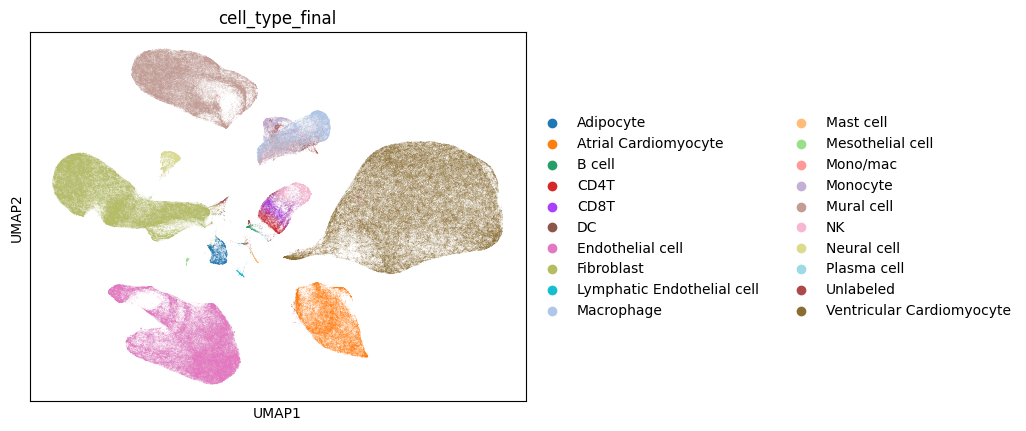

In [ ]:
# sc.pl.umap(adata, color='cell_type_final')

#### concatenation

In [103]:
for_concat

[AnnData object with n_obs × n_vars = 176533 × 32568
     obs: 'GSE_id', 'GSM_id', 'Age', 'Tissue_global', 'cell_type_final'
     var: 'n_cells'
     uns: 'GSE_id_colors', 'GSM_id_colors', '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_final_colors', 'ct_anno_colors', 'hvg', 'leiden', 'leiden_R', 'neighbors', 'scanvi_pred_colors', 'umap'
     obsm: 'X_scANVI', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 356752 × 30984
     obs: 'GSE_id', 'GSM_id', 'Age', 'Tissue_global', 'cell_type_final'
     var: 'n_cells'
     uns: 'Ethnicity_colors', 'GSE_id_colors', 'GSM_id_colors', 'Rejected_after_transplantation_colors', 'Sex_colors', 'Smoker_colors', 'Tissue_colors', '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'leiden_colors', 'neighbors', 'scanvi_pred_colors', 'umap'
     obsm: 'X_scANVI', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs'
     obsp: 'connectivities', 'distances',
 AnnData object with n_ob

In [106]:
adata_full = sc.concat(for_concat, join="outer")
adata_full

AnnData object with n_obs × n_vars = 1456230 × 42947
    obs: 'GSE_id', 'GSM_id', 'Age', 'Tissue_global', 'cell_type_final'
    obsm: 'X_scANVI', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs'

In [121]:
# Check columns with the new float data type
for col in adata_full.obs.columns:
    if isinstance(adata_full.obs[col].array, pd.core.arrays.floating.FloatingArray):
        print(f"⚠️  Column '{col}' has FloatingArray dtype:", adata_full.obs[col].dtype)


⚠️  Column 'Age' has FloatingArray dtype: Float64


In [122]:
adata_full.obs.Age = adata_full.obs.Age.astype(float)
# Done AFTER dropping NAs

In [123]:
adata_full.write("senescence_2/adata_all_harmonized.h5ad")